## LSTM Training

### Load the saved sequences

In [1]:
import json

with open("../data/sequences.json", "r") as f:
    all_sequences = json.load(f)

print(len(all_sequences))

2850


In [2]:
import pandas as pd

df = pd.read_csv("../data/spotify_tracks.csv")

In [4]:
mood_features = [
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "tempo"
]

In [5]:
import numpy as np

X = []
y = []

for seq in all_sequences:

    feature_sequence = (
        df.loc[seq, mood_features]
        .values
    )

    X.append(feature_sequence[:-1])
    y.append(feature_sequence[-1])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2850, 7, 5)
(2850, 5)


### Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42
)

In [9]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2058, 7, 5)
Validation: (364, 7, 5)
Test: (428, 7, 5)


In [10]:
np.savez_compressed(
    "../data/train_val_test_split.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

In [11]:
data = np.load("../data/train_val_test_split.npz")

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

In [12]:
sample_x = X_train[0]
sample_y = y_train[0]

print("Input Sequence:")
print(sample_x)

print("\nTarget:")
print(sample_y)

Input Sequence:
[[7.91000e-01 8.01000e-01 6.16000e-01 4.87000e-02 1.34009e+02]
 [7.91000e-01 8.01000e-01 6.16000e-01 4.87000e-02 1.34009e+02]
 [7.77000e-01 7.37000e-01 6.26000e-01 9.53000e-02 1.20004e+02]
 [8.49000e-01 7.22000e-01 6.63000e-01 7.91000e-02 1.23992e+02]
 [8.49000e-01 7.22000e-01 6.63000e-01 7.91000e-02 1.23992e+02]
 [8.49000e-01 7.22000e-01 6.63000e-01 7.91000e-02 1.23992e+02]
 [8.98000e-01 7.22000e-01 6.54000e-01 8.44000e-02 1.23996e+02]]

Target:
[8.98000e-01 7.22000e-01 6.54000e-01 8.44000e-02 1.23996e+02]


### Model Training

In [13]:
print(X_train.shape)
print(y_train.shape)

(2058, 7, 5)
(2058, 5)


In [14]:
sample_x = X_train[0]
sample_y = y_train[0]

sample_x

array([[7.91000e-01, 8.01000e-01, 6.16000e-01, 4.87000e-02, 1.34009e+02],
       [7.91000e-01, 8.01000e-01, 6.16000e-01, 4.87000e-02, 1.34009e+02],
       [7.77000e-01, 7.37000e-01, 6.26000e-01, 9.53000e-02, 1.20004e+02],
       [8.49000e-01, 7.22000e-01, 6.63000e-01, 7.91000e-02, 1.23992e+02],
       [8.49000e-01, 7.22000e-01, 6.63000e-01, 7.91000e-02, 1.23992e+02],
       [8.49000e-01, 7.22000e-01, 6.63000e-01, 7.91000e-02, 1.23992e+02],
       [8.98000e-01, 7.22000e-01, 6.54000e-01, 8.44000e-02, 1.23996e+02]])

In [15]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from sklearn.metrics import (
    mean_absolute_error
)

### Define Model
Requirements:

- 2 LSTM layers
- Dropout
- Regression output
- MSE loss

In [ ]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = Sequential([
    
    LSTM(
        64,
        return_sequences=True,
        input_shape=(n_timesteps, n_features),
    ),
    
    Dropout(0.3),
    
    LSTM(32),
    
    Dropout(0.3),
    
    Dense(
        16,
        activation='relu'
    ),
    
    Dense(n_features)
])

e:\Learning\AI\Edversity\Hackathon\src\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compile Model

In [18]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,949 (120.89 KB)

 Trainable params: 30,949 (120.89 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

### Train Model

In [24]:
history = model.fit(
    X_train,
    y_train,
    
    validation_data=(
        X_val,
        y_val
    ),
    
    epochs=100,
    
    batch_size=32,
    
    callbacks=[
        early_stop
    ],
    
    verbose=1
)

Epoch 1/100


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 48.0746 - mae: 2.6401 - val_loss: 15.0814 - val_mae: 1.4673
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 51.0172 - mae: 2.7272 - val_loss: 13.6292 - val_mae: 1.3872
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 49.8297 - mae: 2.6697 - val_loss: 13.7663 - val_mae: 1.4079
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 49.4204 - mae: 2.6640 - val_loss: 12.8720 - val_mae: 1.3458
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 52.0899 - mae: 2.7369 - val_loss: 18.7701 - val_mae: 1.6899
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 51.9317 - mae: 2.7414 - val_loss: 13.0709 - val_mae: 1.3598
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 51.8255 - mae: 2.7333 - val_loss: 14.0260 - val_mae: 1.4239
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 51.6877 - mae: 2.7016 - val_loss: 12.8570 - val_mae: 1.3280
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5

### Plot Training Curves

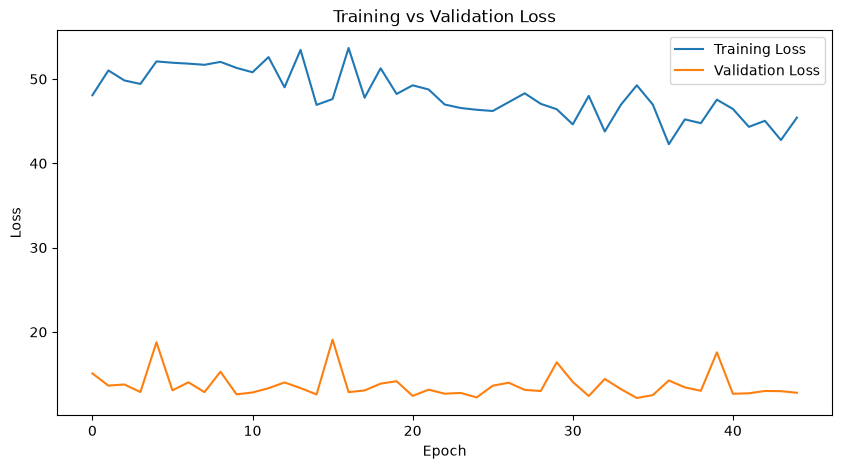

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

### Evaluate on Test Set

In [25]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

Test Loss: 12.788788795471191
Test MAE: 1.3513087034225464


### Generate Predictions

In [26]:
y_pred = model.predict(X_test)

print(y_pred.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(428, 5)


### Compute MAE Per Feature

In [27]:
mood_features = [
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "tempo"
]

In [28]:
feature_mae = {}

for i, feature in enumerate(
    mood_features
):

    mae = mean_absolute_error(
        y_test[:, i],
        y_pred[:, i]
    )

    feature_mae[feature] = mae

print("Feature-wise MAE:")
for feature, mae in feature_mae.items():
    print(f"{feature}: {mae}")

Feature-wise MAE:
energy: 0.2190785334529966
valence: 0.23105199446076544
danceability: 0.14381642789116528
acousticness: 0.2880784732929494
tempo: 5.874518434613664


### Compare Actual vs Predicted

In [29]:
sample_idx = 0

comparison = pd.DataFrame({

    "Feature": mood_features,

    "Actual":
        y_test[sample_idx],

    "Predicted":
        y_pred[sample_idx]
})

comparison

,Feature,Actual,Predicted
0,energy,0.897000,0.818053
1,valence,0.802000,0.598136
2,danceability,0.466000,0.672776
3,acousticness,0.000206,0.209383
4,tempo,159.988000,163.141769


### Save Model

In [30]:
model.save(
    "../models/lstm_next_track.keras"
)